In [64]:
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('../data/raw/media_performance_raw.csv')
print(df.groupby('channel')['conversions'].agg(['mean','median']))

                  mean  median
channel                       
Display       6.247956     6.0
Email        24.010944    22.0
Paid Search  88.791545    82.5
Paid Social  27.272069    25.0
PaidSearch   99.823529    90.0
Paid_Search  78.941176    77.0
Social       22.227273    21.0
Video         6.688797     6.0
paid search  81.941176    78.0
paid_social  30.047619    25.0


In [66]:
df['channel'].value_counts()

channel
Display        734
Email          731
Video          723
Paid Social    691
Paid Search    686
Social          22
paid_social     21
Paid_Search     17
paid search     17
PaidSearch      17
Name: count, dtype: int64

In [67]:
df[df['channel'] == 'Social']['spend'].describe()

count      22.000000
mean      820.267727
std       211.989291
min       524.340000
25%       649.605000
50%       774.630000
75%       965.250000
max      1247.460000
Name: spend, dtype: float64

### Hallazgo 01 — Etiquetas inconsistentes en `channel`

**Detección:** un `groupby('channel')` para comparar media/mediana reveló 10
etiquetas donde debían existir 5 canales.

**Diagnóstico:** `value_counts()` mostró un corte natural — 5 etiquetas con ~700
filas (canónicas) y 5 con 17-22 filas (variantes mal escritas: mayúsculas,
guiones, espacios).

**Caso ambiguo:** `Social` (22 filas) podía ser variante de `Paid Social` o un
canal orgánico legítimo. Se verificó con `spend.describe()`: min = 524 (ningún
cero) → es tráfico pagado → variante de `Paid Social`.

**Fix:** `.replace()` con diccionario de mapeo. Resultado: 5 canales canónicos.

In [68]:
mapa_canales = {
    'PaidSearch': 'Paid Search',
    'Paid_Search': 'Paid Search',
    'paid search': 'Paid Search',
    'Social': 'Paid Social',
    'paid_social': 'Paid Social'
}

df['channel'] = df['channel'].replace(mapa_canales)

In [69]:
print(df['channel'].value_counts())

channel
Paid Search    737
Paid Social    734
Display        734
Email          731
Video          723
Name: count, dtype: int64


In [70]:
# check if mean and median diverge by channel (signal of outliers)
df.groupby('channel')['conversions'].agg(['mean', 'median'])

,mean,median
channel,,
Display,6.247956,6.0
Email,24.010944,22.0
Paid Search,88.660787,82.0
Paid Social,27.200272,24.0
Video,6.688797,6.0


In [71]:
# inspect the distribution edges (min, max, quartiles) per channel
df.groupby('channel')['conversions'].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
Display,734.0,6.247956,2.274742,2.0,5.0,6.0,7.0,25.0
Email,731.0,24.010944,9.714973,9.0,18.0,22.0,27.5,109.0
Paid Search,737.0,88.660787,33.923051,37.0,67.0,82.0,102.0,336.0
Paid Social,734.0,27.200272,11.049286,11.0,21.0,24.0,31.0,130.0
Video,723.0,6.688797,2.611762,3.0,5.0,6.0,8.0,23.0


In [72]:
# isolate the specific row behind the extreme max value in Paid Search
df[(df['channel'] == 'Paid Search') & (df['conversions'] == 336)]

,date,channel,impressions,clicks,spend,conversions,revenue
33,2024-12-02,Paid Search,118380,4069,9615.63,336,23627.29


### Finding 02 — Mixed date formats in `date`

**Detection:** converting `date` with `pd.to_datetime()` raised a `ValueError` —
`"06/20/2024"` didn't match the expected `%Y-%m-%d` format.

**Diagnosis:** `df[df['date'].str.contains('/')]` isolated 10 rows using a
`MM/DD/YYYY` format instead of the dataset's standard `YYYY-MM-DD`. The row
`12/21/2023` resolved the day/month ambiguity — "21" can't be a month, which
confirms month-first (`MM/DD/YYYY`), not day-first.

**Fix:** `pd.to_datetime()` with `format='mixed'` and `dayfirst=False` (explicit,
even though it's the default, to document the ambiguity was checked).

In [73]:
df['date'].sample(20)

3361    2023-11-28
2231    2024-01-12
2192    2024-09-07
1808    2023-12-25
3476    2023-03-27
1408    2023-02-18
2009    2023-08-31
2764    2023-06-21
3445    2024-09-23
1984    2024-09-29
3549    2023-11-06
1120    2023-05-28
3400    2023-05-20
3147    2023-10-11
2632    2024-02-06
3142    2023-02-08
1706    2024-03-13
1210    2024-10-29
2926    2023-05-30
111     2024-06-05
Name: date, dtype: str

In [74]:
# convert date column from text to real datetime dtype
# 'mixed' handles both YYYY-MM-DD (majority) and MM/DD/YYYY (10 rows found)
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=False)

In [75]:
# verify dtype conversion succeeded
df['date'].dtype

dtype('<M8[us]')

In [76]:
# spot-check the ambiguous case: should read as Dec 21, 2023, no error
df[df['date'] == '2023-12-21']

,date,channel,impressions,clicks,spend,conversions,revenue
1040,2023-12-21,Video,58708,571,484.73,11,763.61
1095,2023-12-21,Paid Search,83042,2927,3166.64,151,13173.19
1389,2023-12-21,Email,29318,777,49.71,37,2934.42
1464,2023-12-21,Paid Social,134481,1507,1063.28,35,2859.72
1649,2023-12-21,Display,192879,751,367.09,10,557.58


<Axes: xlabel='date'>

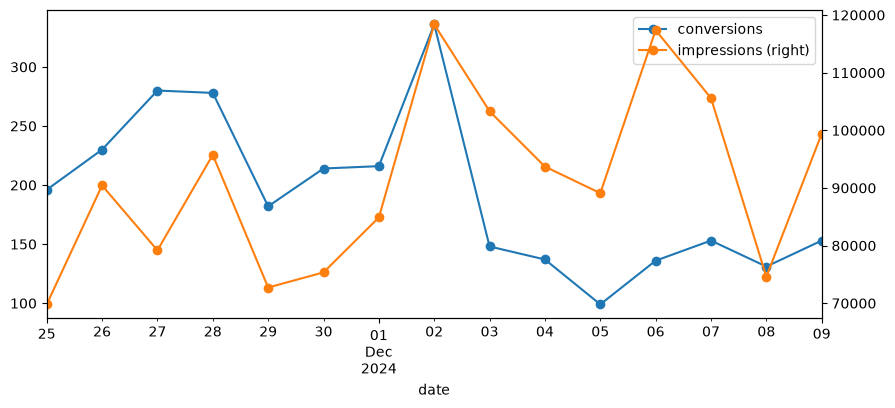

In [77]:
# condición 1: solo canal Paid Search
# condición 2: fecha desde 2024-11-25
# condición 3: fecha hasta 2024-12-09
# combinar las 3 con AND (&) -> mask_window es una Serie de True/False
mask_window =   (df['channel'] == 'Paid Search') & \
                (df['date'] >= '2024-11-25') &\
                (df['date'] <= '2024-12-09')

subset = df[mask_window].sort_values('date')
subset.plot(x='date', y=['conversions', 'impressions'], kind='line', marker='o', secondary_y='impressions' ,figsize=(10,4))

### Finding 03 — Extreme value validated as legitimate (not corrected)

**Detection:** `groupby('channel')['conversions'].describe()` flagged Paid Search's
max (336) as a strong outlier — the jump from the 75th percentile (102) to the
max was ~12x larger than the jump from the median to the 75th percentile.

**Diagnosis:** isolated the row (`2024-12-02`) and plotted a two-week window
around it alongside `impressions` for context. Three independent signals point
to a legitimate business spike rather than a data error:
1. The date aligns with Cyber Monday 2024 — a known high-intent shopping period.
2. `conversions` and `impressions` rise and fall together across the window,
   consistent with a real spend-driven spike (a data error would likely show
   conversions spiking in isolation, decoupled from impressions/spend).
3. The days leading up to the peak (Nov 27–28) already show elevated values —
   a "shoulder" pattern, not an isolated spike surrounded by flat, normal days.

**Conclusion:** the value is kept as-is. Not every extreme value is a data
quality issue — distinguishing a real business spike from a corrupted entry
requires corroborating evidence (date context, correlated metrics, neighboring
values), not just the magnitude of the number itself.

In [78]:
df.duplicated().sum()

np.int64(15)

In [79]:
df.duplicated(subset=['date', 'channel']).sum()

np.int64(15)

In [80]:
df[df.duplicated(subset=['date', 'channel'])].sort_values(['date', 'channel'])

,date,channel,impressions,clicks,spend,conversions,revenue
2021,2023-01-20,Paid Search,37401,1147,1270.86,49,3491.13
2628,2023-02-21,Paid Search,53455,1954,2275.29,77,5234.49
2326,2023-03-03,Paid Social,102783,1410,1028.68,26,1650.01
3519,2023-07-17,Paid Search,53968,1641,2022.05,63,4682.39
2909,2023-09-09,Paid Social,100245,1265,911.15,21,1538.54
2291,2023-09-16,Paid Search,54680,1832,2130.09,53,4241.89
2233,2023-10-13,Paid Search,57414,2182,2818.64,96,8067.56
3382,2023-11-09,Display,214407,993,427.28,11,630.31
3655,2023-12-28,Video,81588,640,676.59,12,821.43
1139,2024-02-25,Paid Social,104593,1153,795.04,24,1109.39


In [81]:
df[df.duplicated(subset=['date', 'channel'], keep=False)].sort_values(['date', 'channel'])

,date,channel,impressions,clicks,spend,conversions,revenue
770,2023-01-20,Paid Search,37401,1147,1270.86,49,3491.13
2021,2023-01-20,Paid Search,37401,1147,1270.86,49,3491.13
477,2023-02-21,Paid Search,53455,1954,2275.29,77,5234.49
2628,2023-02-21,Paid Search,53455,1954,2275.29,77,5234.49
1718,2023-03-03,Paid Social,102783,1410,1028.68,26,1650.01
2326,2023-03-03,Paid Social,102783,1410,1028.68,26,1650.01
1428,2023-07-17,Paid Search,53968,1641,2022.05,63,4682.39
3519,2023-07-17,Paid Search,53968,1641,2022.05,63,4682.39
2485,2023-09-09,Paid Social,100245,1265,911.15,21,1538.54
2909,2023-09-09,Paid Social,100245,1265,911.15,21,1538.54


In [82]:
df.shape

(3659, 7)

In [83]:
df = df.drop_duplicates()

In [84]:
df.shape

(3644, 7)

In [85]:
df.duplicated().sum()

np.int64(0)

### Finding 04 — Exact duplicate rows

**Detection:** `df.duplicated().sum()` returned 15 rows flagged as exact
duplicates (all columns matching a previous row).

**Diagnosis:** before dropping anything, checked whether these were full
duplicates (same row copied twice — safe to drop) or same date+channel with
different metric values (a conflict requiring a rule to resolve). Comparing
`df.duplicated(subset=['date','channel']).sum()` against the full-row count
showed the same number (15) either way, and inspecting the pairs with
`keep=False` confirmed every column matched exactly across each pair — no
value conflicts. Likely caused by overlapping data pulls during file
generation (duplicate row indices were far apart, not adjacent).

**Fix:** `df.drop_duplicates()` — safe with default settings since duplicates
were confirmed as full-row copies. Shape went from (3659, 7) to (3644, 7),
matching the expected 15-row reduction.